# 車牌辨識(Automatic Number Plate Recognition, ANPR)
### 程式修改自 [Car License Plate Recognition using Raspberry Pi and OpenCV](https://circuitdigest.com/microcontroller-projects/license-plate-recognition-using-raspberry-pi-and-opencv)

## 載入相關套件

In [1]:
# 載入相關套件
import cv2
import imutils
import matplotlib.pyplot as plt
import numpy as np
import pytesseract

## 載入並顯示圖檔

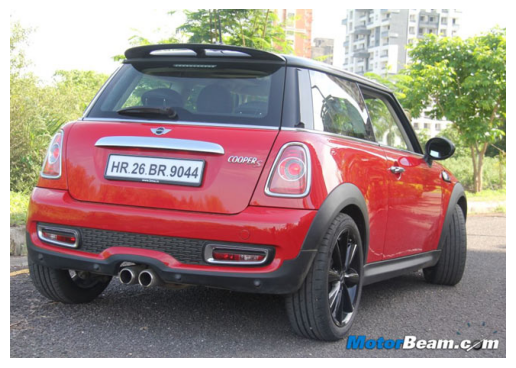

In [ ]:
# 載入圖檔
image = cv2.imread('./images_ocr/2.jpg', cv2.IMREAD_COLOR)

# 顯示圖檔
image_RGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_RGB)
plt.axis('off')
plt.show()

## 車牌號碼 OCR 辨識

In [3]:
# 車牌號碼 OCR 辨識
char_whitelist = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ1234567890'
text = pytesseract.image_to_string(image, config=f'-c tessedit_char_whitelist={char_whitelist} --psm 6 ')
print("車牌號碼：", text)

車牌號碼： CO S
I
BQ A
CO B



## 轉為灰階，萃取輪廓

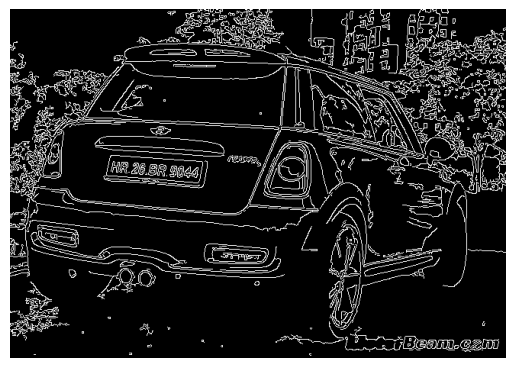

In [4]:
# 萃取輪廓
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # 轉為灰階
gray = cv2.bilateralFilter(gray, 11, 17, 17)  # 模糊化，去除雜訊
edged = cv2.Canny(gray, 30, 200)  # 萃取輪廓

# 顯示圖檔
plt.imshow(edged, cmap='gray')
plt.axis('off')
plt.show()

## 取得等高線區域，並排序，取前10個區域

In [ ]:
# 取得等高線區域，並排序，取前10個區域
cnts_raw = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts_raw)
cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:10]

In [6]:
cnts[0].shape

(3351, 1, 2)

## 找第一個含四個點的等高線區域

In [7]:
# 找第一個含四個點的等高線區域
screenCnt = None
for i, c in enumerate(cnts):
    # 計算等高線區域周長
    peri = cv2.arcLength(c, True)
    # 轉為近似多邊形
    approx = cv2.approxPolyDP(c, 0.018 * peri, True)
    # 等高線區域維度
    print(c.shape)

    # 找第一個含四個點的多邊形
    if len(approx) == 4:
        screenCnt = approx
        print(i)
        break

(3351, 1, 2)
(411, 1, 2)
(335, 1, 2)
(184, 1, 2)
(114, 1, 2)
4


## 在原圖上繪製多邊形，框住車牌

In [8]:
# 在原圖上繪製多邊形，框住車牌
if screenCnt is None:
    detected = 0
    print("No contour detected")
else:
    detected = 1

assert screenCnt is not None
if detected == 1:
    cv2.drawContours(image, [screenCnt], -1, (0, 255, 0), 3)
    print(f'車牌座標=\n{screenCnt}')

車牌座標=
[[[122 219]]

 [[246 227]]

 [[252 200]]

 [[132 191]]]


## 去除車牌以外的圖像，找出車牌的上下左右的座標，計算車牌寬高

In [9]:
# 去除車牌以外的圖像
mask = np.zeros(gray.shape, np.uint8)
assert screenCnt is not None
new_image = cv2.drawContours(
    mask,
    [screenCnt],
    0,
    (255,),
    -1,
)
new_image = cv2.bitwise_and(image, image, mask=mask)

# 轉為浮點數
src_pts = np.array(screenCnt, dtype=np.float32)

# 找出車牌的上下左右的座標
left = min([x[0][0] for x in src_pts])
right = max([x[0][0] for x in src_pts])
top = min([x[0][1] for x in src_pts])
bottom = max([x[0][1] for x in src_pts])

# 計算車牌寬高
width = right - left
height = bottom - top
print(f'寬度={width}, 高度={height}')

寬度=130.0, 高度=36.0


## 仿射(affine transformation)，將車牌轉為矩形

In [10]:
# 計算仿射(affine transformation)的目標區域座標，須與擷取的等高線區域座標順序相同
if src_pts[0][0][0] > src_pts[1][0][0] and src_pts[0][0][1] < src_pts[3][0][1]:
    print('起始點為右上角')
    dst_pts = np.array([[width, 0], [0, 0], [0, height], [width, height]], dtype=np.float32)
elif src_pts[0][0][0] < src_pts[1][0][0] and src_pts[0][0][1] > src_pts[3][0][1]:
    print('起始點為左下角')
    dst_pts = np.array([[0, height], [width, height], [width, 0], [0, 0]], dtype=np.float32)
else:
    print('起始點為左上角')
    dst_pts = np.array([[0, 0], [0, height], [width, height], [width, 0]], dtype=np.float32)

# 仿射
M = cv2.getPerspectiveTransform(src_pts, dst_pts)
Cropped = cv2.warpPerspective(gray, M, (int(width), int(height)))

起始點為左下角


## 車牌號碼 OCR 辨識

In [11]:
# 車牌號碼 OCR 辨識
char_whitelist = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ1234567890'
text = pytesseract.image_to_string(Cropped, config=f'-c tessedit_char_whitelist={char_whitelist} --psm 6 ')
print("車牌號碼：", text)

車牌號碼： HR26BR9044



## 顯示原圖及車牌

In [ ]:
# 顯示原圖及車牌
cv2.imshow('Orignal image', image)
cv2.imshow('Cropped image', Cropped)

# 車牌存檔
cv2.imwrite('Cropped.jpg', Cropped)

# 按 Enter 鍵結束
cv2.waitKey(0)

# 關閉所有視窗
cv2.destroyAllWindows()

: 